In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


In [2]:
df = pd.read_csv('../data/supply_chain_cleaned.csv')

date_columns = ['order_date_dateorders', 'shipping_date_dateorders']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'Shape: {df.shape}')
df.head()


Shape: (180519, 62)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,order_year,order_month,order_day,order_dayofweek,order_quarter,order_hour,is_weekend,shipping_year,shipping_month,actual_shipping_delay,is_early_or_ontime,order_to_shipping_hours,order_season
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,1,22,0,2018,2,-1.00,1,72.00,Winter
1,TRANSFER,5,4,-79.70,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-79.70,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,1,12,1,2018,1,1.00,0,120.00,Winter
2,CASH,4,4,-79.70,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,Gillian,19491,Maldonado,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-79.70,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,2018,1,13,5,1,12,1,2018,1,0.00,1,96.00,Winter
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,Tana,19490,Tate,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,2018,1,13,5,1,11,1,2018,1,-1.00,1,72.00,Winter
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Orli,19489,Hendricks,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2018,1,13,5,1,11,1,2018,1,-1.50,1,48.00,Winter


In [3]:
display(df.describe().T)

cat_cols = df.select_dtypes(include='object').columns
summary = pd.DataFrame({
    'unique_values': df[cat_cols].nunique(),
    'top_value': df[cat_cols].apply(lambda s: s.mode().iloc[0] if not s.mode().empty else 'N/A'),
    'top_freq_pct': df[cat_cols].apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
})
display(summary.sort_values('unique_values', ascending=False))


,count,mean,min,25%,50%,75%,max,std
days_for_shipping_real,"180,519.00",3.50,0.00,2.00,3.00,5.00,6.00,1.62
days_for_shipment_scheduled,"180,519.00",2.93,0.00,2.00,4.00,4.00,4.00,1.37
benefit_per_order,"180,519.00",32.85,-79.70,7.00,31.52,64.80,151.50,55.25
sales_per_customer,"180,519.00",180.60,7.49,104.38,163.99,247.40,461.93,104.38
late_delivery_risk,"180,519.00",0.55,0.00,0.00,1.00,1.00,1.00,0.50
category_id,"180,519.00",31.85,2.00,18.00,29.00,45.00,76.00,15.64
customer_id,"180,519.00","6,691.38",1.00,"3,258.50","6,457.00","9,779.00","20,757.00","4,162.92"
customer_zipcode,"180,519.00","35,920.85",603.00,725.00,"19,380.00","78,207.00","99,205.00","37,542.21"
department_id,"180,519.00",5.44,2.00,4.00,5.00,7.00,12.00,1.63
latitude,"180,519.00",29.72,-33.94,18.27,33.14,39.28,48.78,9.81


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_18076/1815145429.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,unique_values,top_value,top_freq_pct
customer_street,7458,9126 Wishing Expressway,0.07
order_city,3597,Santo Domingo,1.22
customer_lname,1110,Smith,35.51
order_state,1089,Inglaterra,3.72
customer_fname,782,Mary,36.09
customer_city,563,Caguas,36.99
order_country,164,Estados Unidos,13.76
product_name,118,Perfect Fitness Perfect Rip Deck,13.58
product_image,118,http://images.acmesports.sports/Perfect+Fitnes...,13.58
category_name,50,Cleats,13.60


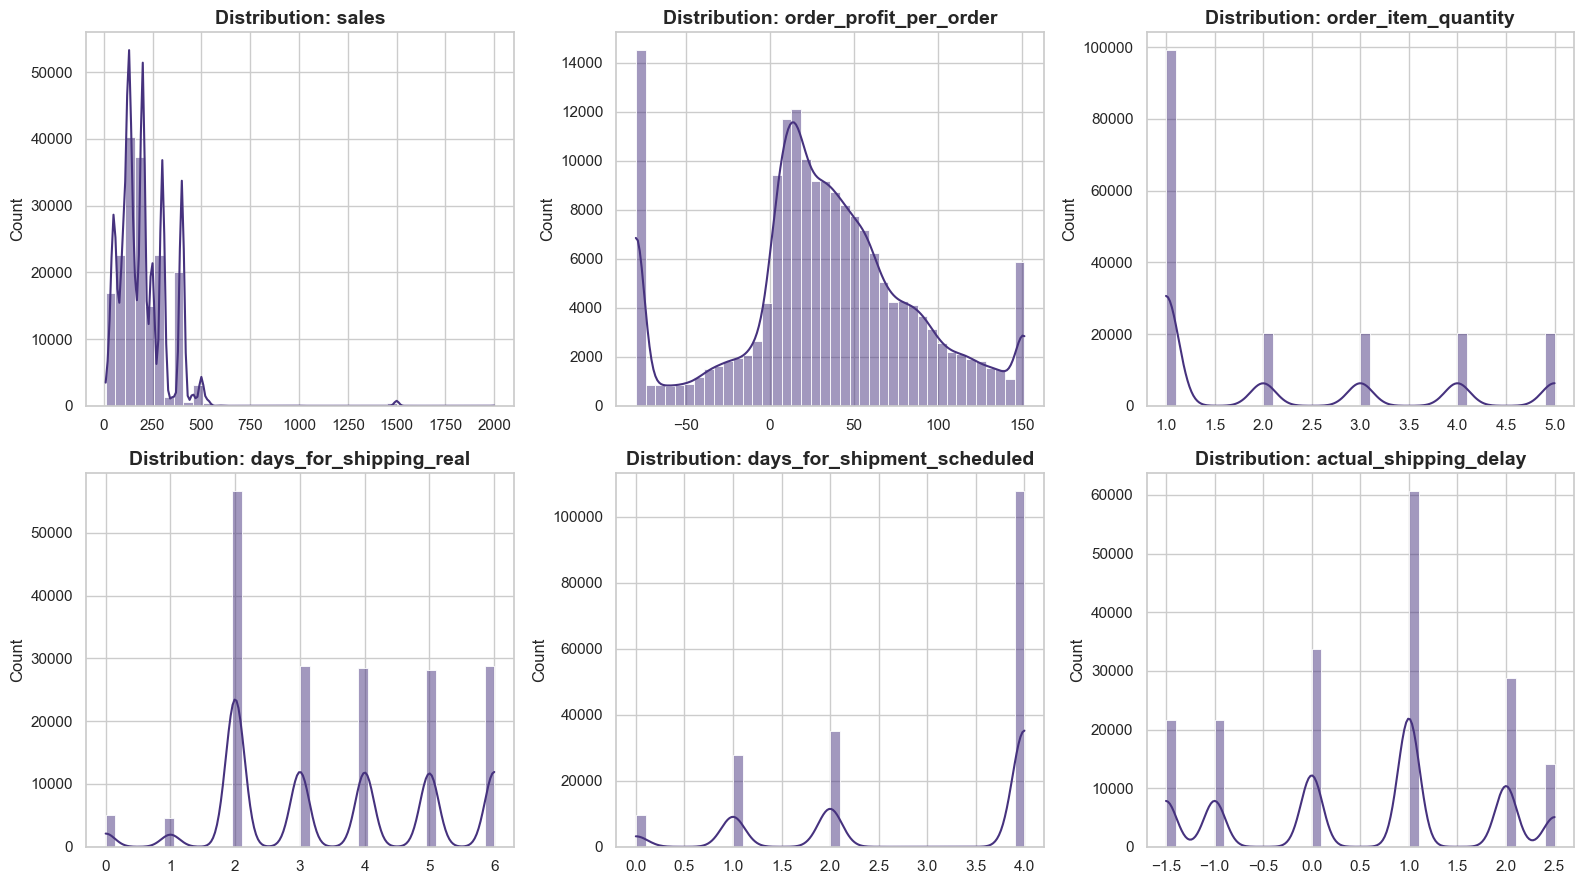

In [4]:
numeric_features = [
    'sales', 'order_profit_per_order', 'order_item_quantity',
    'days_for_shipping_real', 'days_for_shipment_scheduled', 'actual_shipping_delay'
]
numeric_features = [c for c in numeric_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel('')

for ax in axes.flatten()[len(numeric_features):]:
    ax.set_visible(False)

save_fig('01_numeric_distributions')
plt.show()


✅ On-Time Delivery Rate: 42.7%
❌ Late Delivery Rate:   57.3%


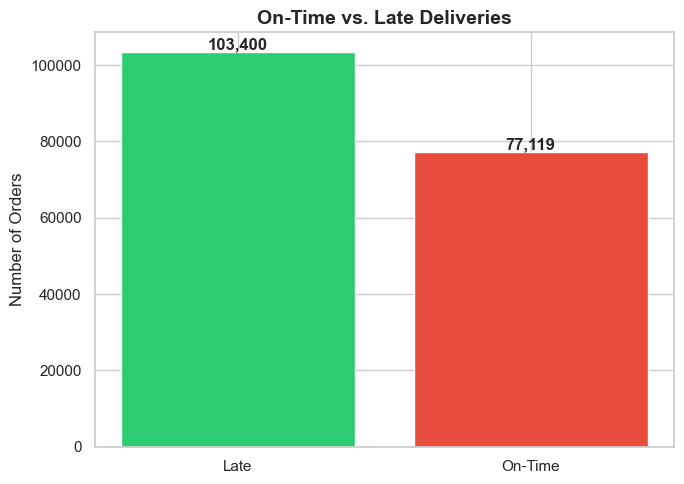

In [5]:
if 'is_early_or_ontime' in df.columns:
    otif_rate = df['is_early_or_ontime'].mean() * 100
    print(f'\u2705 On-Time Delivery Rate: {otif_rate:.1f}%')
    print(f'\u274c Late Delivery Rate:   {100 - otif_rate:.1f}%')

    fig, ax = plt.subplots(figsize=(7, 5))
    counts = df['is_early_or_ontime'].map({1: 'On-Time', 0: 'Late'}).value_counts()
    colors = ['#2ecc71', '#e74c3c']
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title('On-Time vs. Late Deliveries')
    ax.set_ylabel('Number of Orders')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    save_fig('02_ontime_vs_late')
    plt.show()


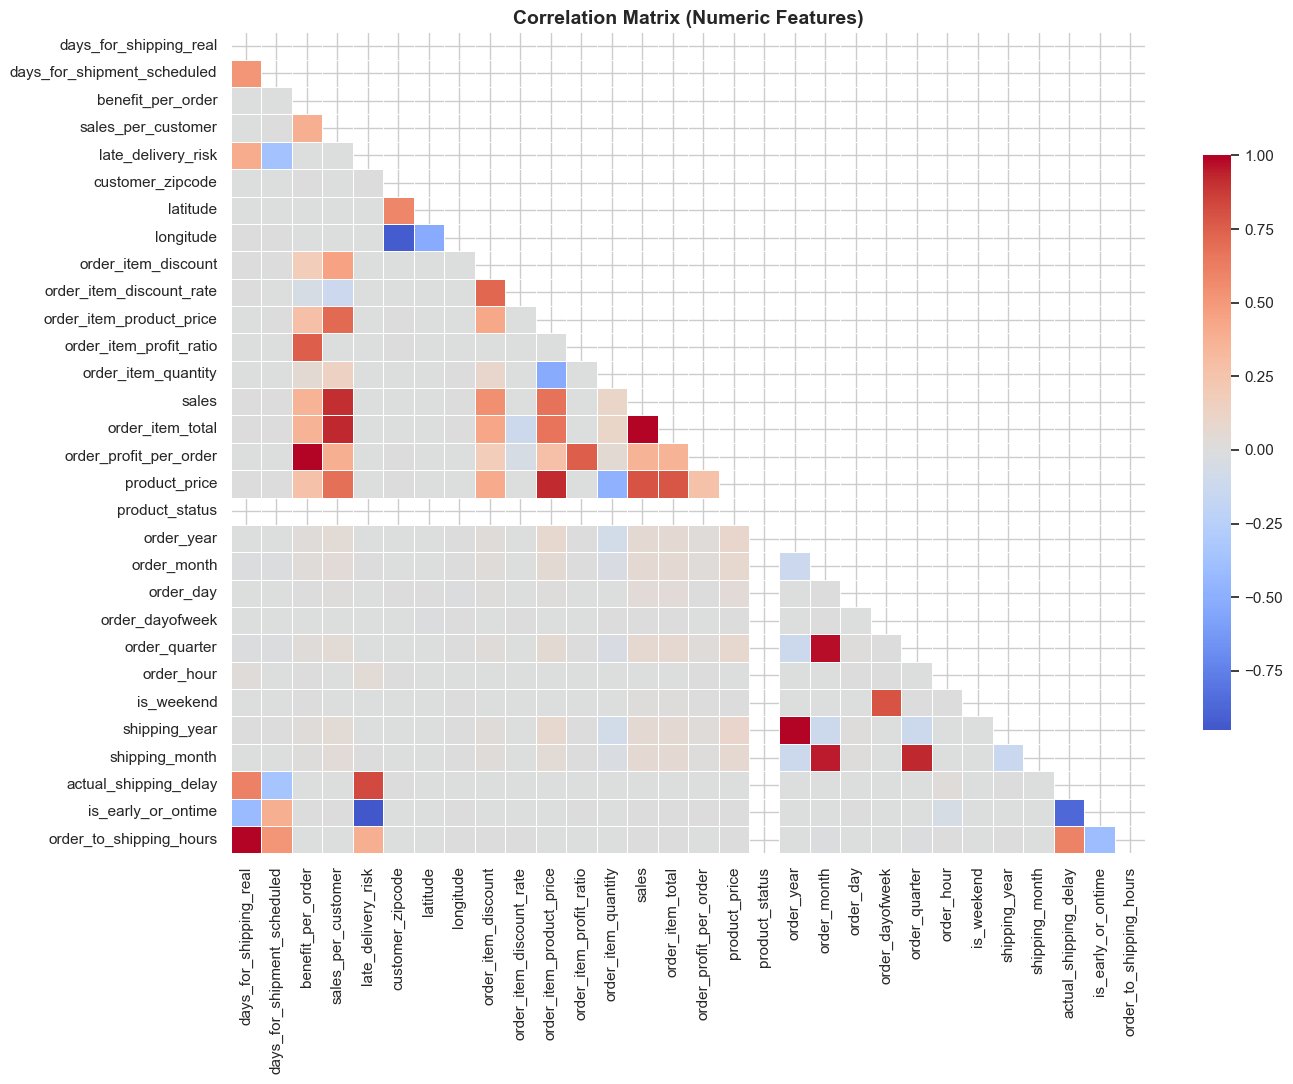


Top 10 strongest correlations:


,feature_1,feature_2,correlation,abs_corr
452,order_profit_per_order,benefit_per_order,1.00,1.00
870,order_to_shipping_hours,days_for_shipping_real,1.00,1.00
768,shipping_year,order_year,0.99,0.99
433,order_item_total,sales,0.99,0.99
679,order_quarter,order_month,0.97,0.97
799,shipping_month,order_month,0.95,0.95
844,is_early_or_ontime,late_delivery_risk,-0.95,0.95
802,shipping_month,order_quarter,0.93,0.93
423,order_item_total,sales_per_customer,0.93,0.93
215,longitude,customer_zipcode,-0.92,0.92


In [6]:
corr_cols = df.select_dtypes(include=np.number).columns
id_like = [c for c in corr_cols if 'id' in c.lower() or 'card' in c.lower()]
corr_cols = [c for c in corr_cols if c not in id_like]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix (Numeric Features)')
save_fig('03_correlation_heatmap')
plt.show()

corr_pairs = (
    corr.where(~mask).stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
print('\nTop 10 strongest correlations:')
display(corr_pairs.sort_values('abs_corr', ascending=False).head(10))


,orders,late_rate,avg_delay
shipping_mode,,,
First Class,27814,100.00,1.00
Second Class,35216,79.73,1.59
Same Day,9737,47.83,0.48
Standard Class,107752,39.77,0.10


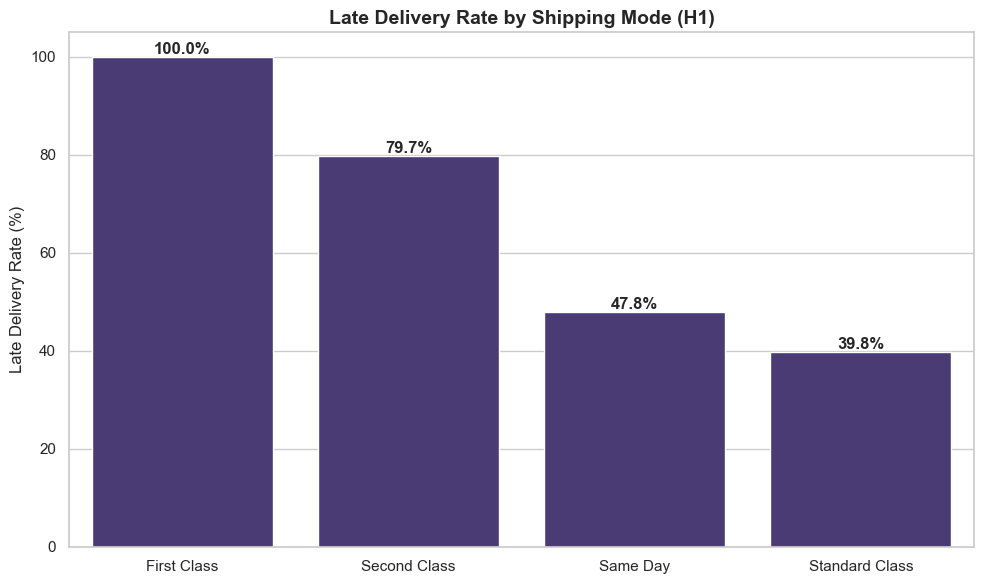

In [7]:
mode_col = 'shipping_mode' if 'shipping_mode' in df.columns else None

if mode_col:
    mode_stats = (
        df.groupby(mode_col)
        .agg(
            orders=('is_early_or_ontime', 'size'),
            late_rate=('is_early_or_ontime', lambda s: (1 - s.mean()) * 100),
            avg_delay=('actual_shipping_delay', 'mean')
        )
        .sort_values('late_rate', ascending=False)
    )
    display(mode_stats)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=mode_stats.index, y=mode_stats['late_rate'], ax=ax)
    ax.set_title('Late Delivery Rate by Shipping Mode (H1)')
    ax.set_ylabel('Late Delivery Rate (%)')
    ax.set_xlabel('')
    for i, v in enumerate(mode_stats['late_rate']):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
    save_fig('04_late_rate_by_mode')
    plt.show()


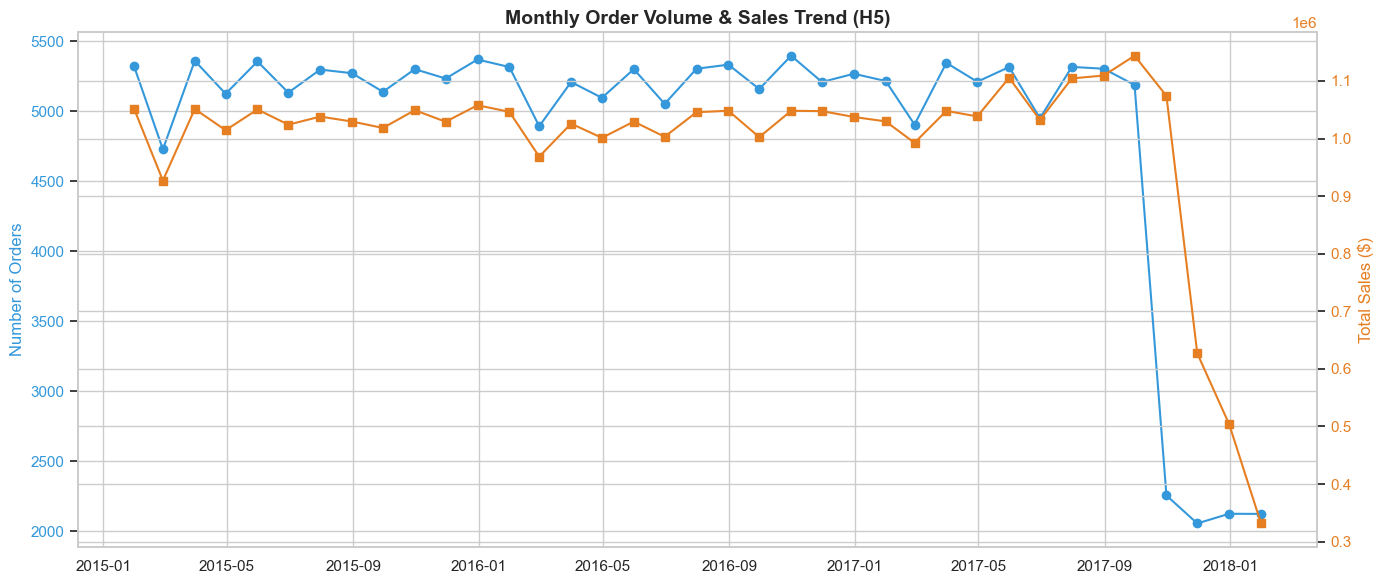

In [8]:
if 'order_date_dateorders' in df.columns:
    ts = (
        df.set_index('order_date_dateorders')
        .resample('ME')
        .agg(orders=('sales', 'size'), total_sales=('sales', 'sum'))
        .dropna()
    )

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(ts.index, ts['orders'], color='#3498db', marker='o', label='Orders')
    ax1.set_ylabel('Number of Orders', color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')

    ax2 = ax1.twinx()
    ax2.plot(ts.index, ts['total_sales'], color='#e67e22', marker='s', label='Sales')
    ax2.set_ylabel('Total Sales ($)', color='#e67e22')
    ax2.tick_params(axis='y', labelcolor='#e67e22')

    plt.title('Monthly Order Volume & Sales Trend (H5)')
    save_fig('05_monthly_trend')
    plt.show()


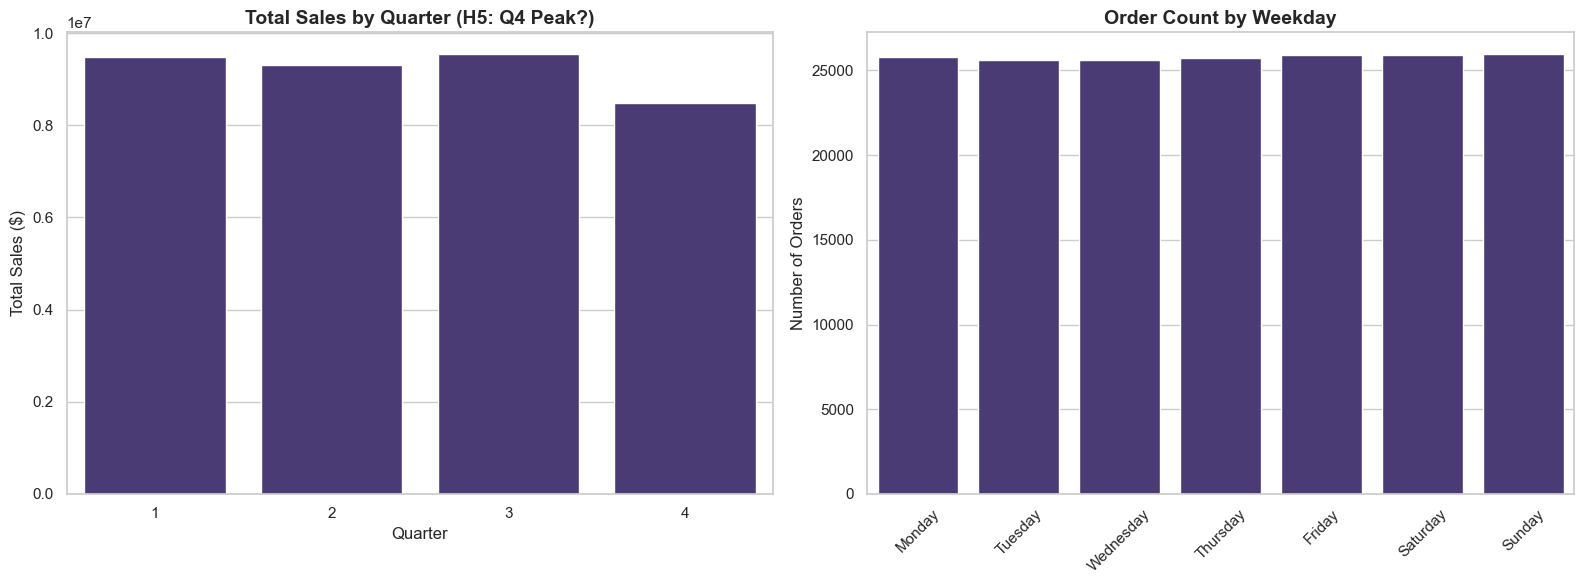

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'order_quarter' in df.columns:
    q = df.groupby('order_quarter')['sales'].sum()
    sns.barplot(x=q.index, y=q.values, ax=axes[0])
    axes[0].set_title('Total Sales by Quarter (H5: Q4 Peak?)')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Total Sales ($)')

if 'order_dayofweek' in df.columns:
    weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
                   3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
    df['order_weekday'] = df['order_dayofweek'].map(weekday_map)
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                     'Friday', 'Saturday', 'Sunday']
    w = df.groupby('order_weekday')['sales'].size().reindex(weekday_order)
    sns.barplot(x=w.index, y=w.values, ax=axes[1])
    axes[1].set_title('Order Count by Weekday')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Number of Orders')
    axes[1].tick_params(axis='x', rotation=45)

save_fig('06_seasonality')
plt.show()


,mean,median,count
is_early_or_ontime,,,
Late,32.67,31.43,103400
On-Time,33.08,31.68,77119


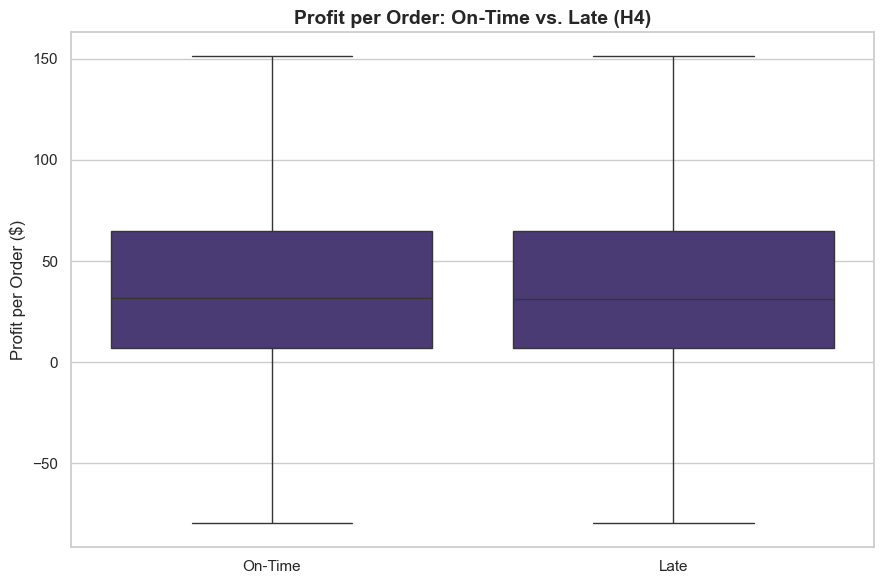

In [10]:
if {'is_early_or_ontime', 'order_profit_per_order'}.issubset(df.columns):
    profit_by_status = (
        df.groupby(df['is_early_or_ontime'].map({1: 'On-Time', 0: 'Late'}))
        ['order_profit_per_order']
        .agg(['mean', 'median', 'count'])
    )
    display(profit_by_status)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(
        data=df,
        x=df['is_early_or_ontime'].map({1: 'On-Time', 0: 'Late'}),
        y='order_profit_per_order',
        showfliers=False,
        ax=ax
    )
    ax.set_title('Profit per Order: On-Time vs. Late (H4)')
    ax.set_xlabel('')
    ax.set_ylabel('Profit per Order ($)')
    save_fig('07_profit_by_delivery_status')
    plt.show()


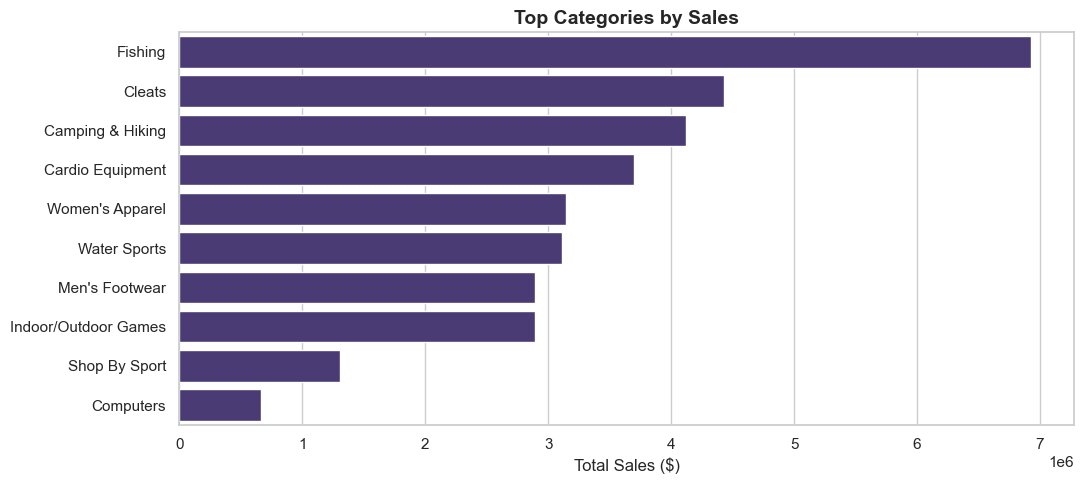

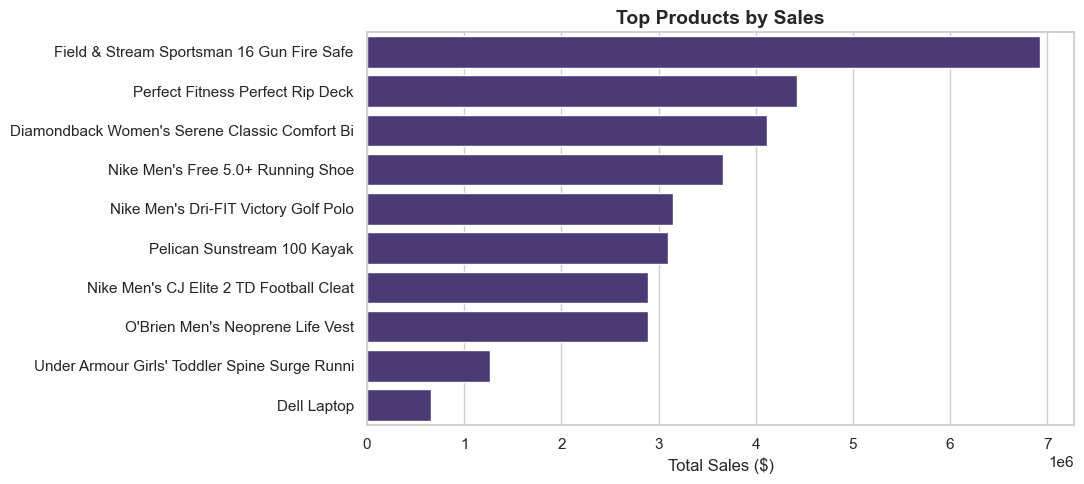

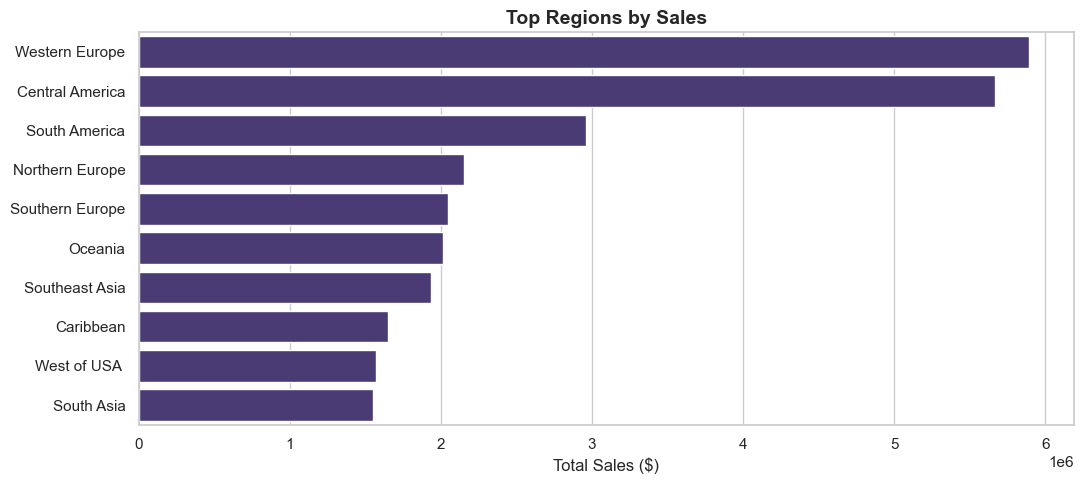

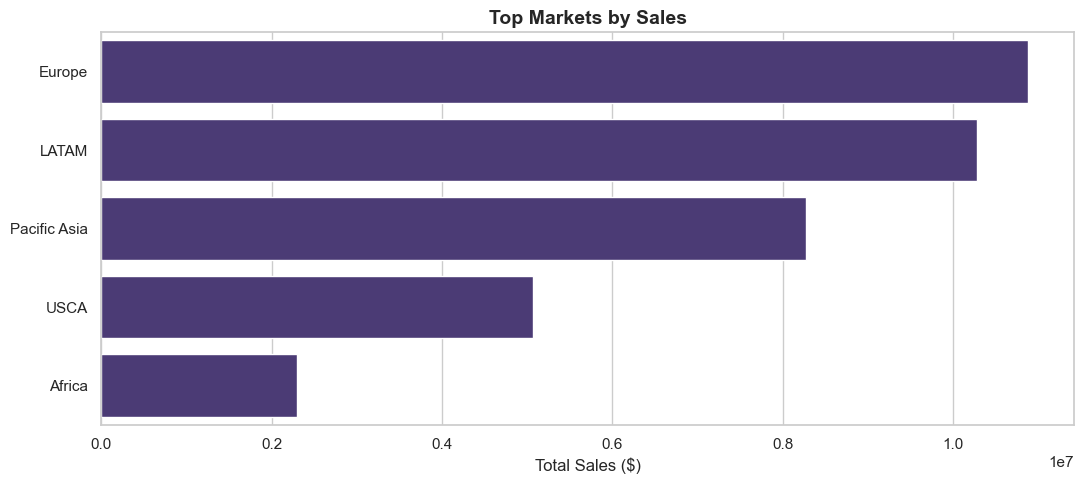

In [11]:
top_dims = {
    'category_name': 'Top Categories by Sales',
    'product_name': 'Top Products by Sales',
    'order_region': 'Top Regions by Sales',
    'market': 'Top Markets by Sales'
}

for col, title in top_dims.items():
    if col in df.columns:
        top = df.groupby(col)['sales'].sum().sort_values(ascending=False).head(10)
        fig, ax = plt.subplots(figsize=(11, 5))
        sns.barplot(x=top.values, y=top.index, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Total Sales ($)')
        ax.set_ylabel('')
        save_fig(f'08_top_{col}')
        plt.show()


In [12]:
print('=' * 60)
print('\U0001f4cb EDA KEY FINDINGS SUMMARY')
print('=' * 60)

if 'is_early_or_ontime' in df.columns:
    print(f'\n\u2022 On-Time Delivery Rate: {df["is_early_or_ontime"].mean()*100:.1f}%')

if 'actual_shipping_delay' in df.columns:
    print(f'\u2022 Average Shipping Delay: {df["actual_shipping_delay"].mean():.2f} days')
    print(f'\u2022 Worst-case Delay: {df["actual_shipping_delay"].max():.0f} days')

if mode_col:
    worst_mode = mode_stats.index[0]
    print(f'\u2022 Most Delay-Prone Mode: {worst_mode} '
          f'({mode_stats.loc[worst_mode, "late_rate"]:.1f}% late)')

if 'order_profit_per_order' in df.columns:
    print(f'\u2022 Total Profit: ${df["order_profit_per_order"].sum():,.0f}')
    print(f'\u2022 Total Sales:  ${df["sales"].sum():,.0f}')

print('\n\u2705 All visuals saved to /visuals for reuse in README & dashboard.')


📋 EDA KEY FINDINGS SUMMARY

• On-Time Delivery Rate: 42.7%
• Average Shipping Delay: 0.55 days
• Worst-case Delay: 2 days
• Most Delay-Prone Mode: First Class (100.0% late)
• Total Profit: $5,929,486
• Total Sales:  $36,784,735

✅ All visuals saved to /visuals for reuse in README & dashboard.
